Buidling a Nueral Network that maps a given time, t to a position of mass, x undergoing a simple harmonic motion.

###Formulae
Standard solution to a simple harmonic oscillator:

x(t) = A cos(ωt)

Set A=1, and ω=1 for now, so that we have x=cos(t)

##Import Libraries and Generate Data

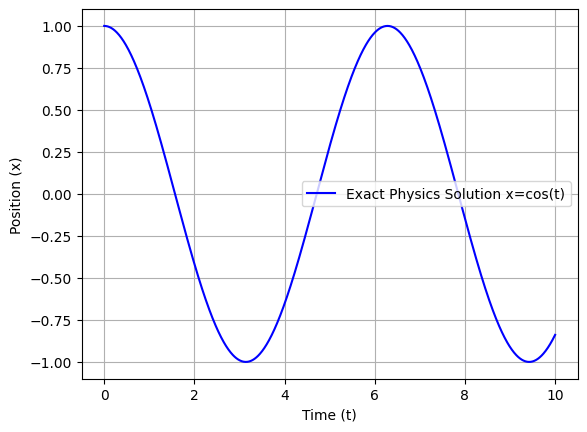

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Generate physics data
np.random.seed(42)
t_data = np.linspace(0, 10, 1000, dtype=np.float32).reshape(-1, 1) #PyTorch linear layers expect input in the form (sample, features)
x_data = np.cos(t_data)  # Target: x = cos(t)

# 2. Convert NumPy arrays to PyTorch Tensors
t_tensor = torch.from_numpy(t_data)
x_tensor = torch.from_numpy(x_data)

# 3. Plot the data to see what we are learning
plt.plot(t_data, x_data, label='Exact Physics Solution x=cos(t)', color='blue')
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.legend()
plt.grid(True)
plt.show()

##Define the Neural Network Architecture
Harmonic motion is defined by acceleration, which is the second derivative of position ($\frac{d^2x}{dt^2}$).


1. **Deciding the Activation Function**

ReLU (Rectified Linear Unit): ReLU is a piecewise linear function ($f(x) = \max(0, x)$). If you take the first derivative of ReLU, you get a step function. If you take the second derivative, it becomes zero everywhere (and undefined at the corner). Because its second derivative is zero, a standard ReLU network literally cannot compute or understand acceleration natively.ReLU outputs straight lines.

Tanh (Hyperbolic Tangent): Tanh is an infinitely differentiable, smooth S-curve. You can take its derivative, and its derivative's derivative, infinitely many times. This allows the network to model smooth physical transitions and accelerations perfectly. Tanh naturally outputs smooth curves that bound between -1 and 1. Because a cosine wave also naturally oscillates smoothly between -1 and 1, the network only needs a few Tanh curves combined to perfectly mimic a physics wave.

2. **Deciding Loss Function**
Choose a loss function based on the output type of our problem, whether it is regression or a classification problem. The harmonic oscillator problem outputs continous values, so this is a regression problem. MSE is standard for regression.

3. **Gradient Descent**
Combines Momentum (storing the moving average of past gradients) and RMSProp (storing the moving average of past squared gradients).
It is the current baseline for almost all modern deep learning. It requires very little hyperparameter tuning, and scales nicely.


In [3]:
class HarmonicNetwork(nn.Module):
    def __init__(self):
        super(HarmonicNetwork, self).__init__()
        # Input: 1 feature (Time 't') -> Output: 1 feature (Position 'x')
        self.network = nn.Sequential(
            nn.Linear(1, 32),   # Input layer to Hidden Layer 1. Takes 1 input variable (Time $t$) and expands it into 32 different features/neurons in the first hidden layer.
            nn.Tanh(),          # Smooth activation
            nn.Linear(32, 32),  # Hidden Layer 1 to Hidden Layer 2. Takes those 32 features and mixes them into 32 new features in the second hidden layer
            nn.Tanh(),          # Smooth activation
            nn.Linear(32, 1)    # Hidden Layer 2 to Output layer. Compresses those 32 features back down into 1 single output
        )

    def forward(self, t):  #forward propogation
        return self.network(t)

# Instantiate the model, define MSE loss, and choose Adam optimizer
model = HarmonicNetwork()
criterion = nn.MSELoss()  #Mean Squared Error, measures the average squared distance between true and predicted values.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

##Train the Model
Let the network loop through the data 1,000 times (epochs). In each loop, it will make a guess, calculate how far off it is using Mean Squared Error (MSE), and adjust its internal weights.

In [4]:
epochs = 100

for epoch in range(epochs):
    # Forward pass: Predict x given t
    predictions = model(t_tensor)

    # Calculate loss (error)
    loss = criterion(predictions, x_tensor)

    # Backward pass and optimization
    optimizer.zero_grad() # Clear old gradients
    loss.backward()       # Compute gradients (calculus!)
    optimizer.step()      # Update weights

    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

Epoch [100/100], Loss: 0.036179


##Evaluate the model

Pass the time tensor back through the trained model and plot the AI's predictions overlapping the actual cosine wave.

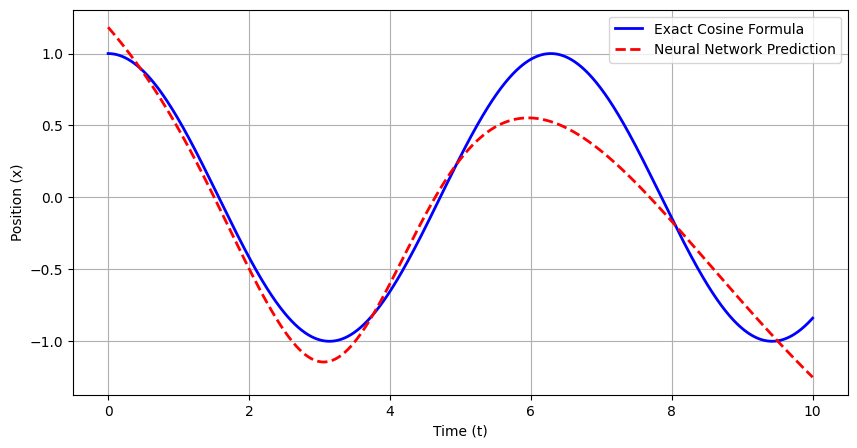

In [7]:
# Turn off gradient tracking for evaluation
with torch.no_grad():
    predicted_x = model(t_tensor).numpy()

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(t_data, x_data, label='Exact Cosine Formula', color='blue', linewidth=2)
plt.plot(t_data, predicted_x, '--', label='Neural Network Prediction', color='red', linewidth=2)
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.legend()
plt.grid(True)
plt.show()

Why do we see underfitting? Our epoch value is 100, low, while the learning rate is high, 0.01. A high learning rate makes large weight updates. We can either set number of epoch to be 1000, or reduce the learning rate to 0.001.

In [8]:
epochs = 1000

for epoch in range(epochs):
    # Forward pass: Predict x given t
    predictions = model(t_tensor)

    # Calculate loss (error)
    loss = criterion(predictions, x_tensor)

    # Backward pass and optimization
    optimizer.zero_grad() # Clear old gradients
    loss.backward()       # Compute gradients (calculus!)
    optimizer.step()      # Update weights

    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

Epoch [100/1000], Loss: 0.012014
Epoch [200/1000], Loss: 0.011416
Epoch [300/1000], Loss: 0.006067
Epoch [400/1000], Loss: 0.004935
Epoch [500/1000], Loss: 0.004115
Epoch [600/1000], Loss: 0.003368
Epoch [700/1000], Loss: 0.002764
Epoch [800/1000], Loss: 0.002147
Epoch [900/1000], Loss: 0.001699
Epoch [1000/1000], Loss: 0.001331


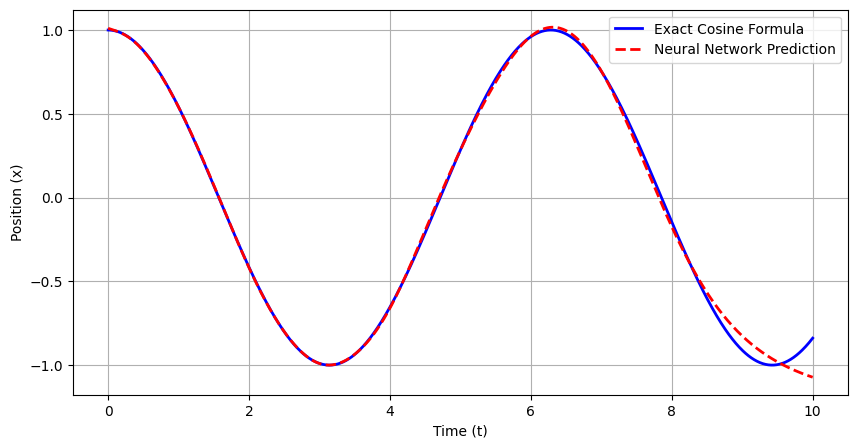

In [9]:
# Turn off gradient tracking for evaluation
with torch.no_grad():
    predicted_x = model(t_tensor).numpy()

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(t_data, x_data, label='Exact Cosine Formula', color='blue', linewidth=2)
plt.plot(t_data, predicted_x, '--', label='Neural Network Prediction', color='red', linewidth=2)
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.legend()
plt.grid(True)
plt.show()

And we get a better result!